In [ ]:
import pandas as pd
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as mpl
import seaborn as sb

from wordcloud import WordCloud

In [ ]:
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
csv = os.path.join(path, 'AB_NYC_2019.csv') # Combines the dataset path and CSV file
data = pd.read_csv(csv) # Loads the obtained data into a DataFrame

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.


## Cleaning Data

The next four cells are dedicated to identifying what the dataset looks like: the first five rows, last five, and provides central tendency measures and other numerical data.

In [ ]:
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
data.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23


In [ ]:
data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

Prior to analyzing the data that the simple python code provided, I had some expectations. Given the area (NYC), I was expecting a high cost for pricing and approximately 5 nights for minimum nights. In regards to the reviews, I wasn't expecting a high number as, from my observations, people tend to not review and not a lot of reservations would occur in one month.

Once finally observing the results of "data.describe()," some anomalies I took note of was the minimum price being $0; this is very likely to be invalid as a host wouldn't list their place for free as there is no benefit for them. For the max of minimum nights, it would be very odd for a host to have people stay for a minimum of approximately 3.5 years (1,250 days / 365). There are also values I found odd for the max of reviews_per_month and calculated_host_listings count. For the latter, I may find it reasonable due to personal observations on "ambition" and wealth in the city.

To identify what may be causing these errors, I also used the info() command. By looking at the provided "Non-Null Count" column, it demonstrated many had missing values. To address this, I imputed and removed rows that may be identified as invalid. For listings with missing reviews_per_month, if it had 0 number_of_reviews, it was made 0 as well. The last_review column was addressed by adding a "flag." Listings with a price of 0.00 are removed, as well as those greater than 1,000.00. There is some hesitancy in removing listings with an availability_365 value of 0; it is reasonable if the host paused it.

In [ ]:
data = data.drop_duplicates() # If there are duplicates, we do not want to overcount and mess with the distributions

# BELOW LINE SHOULD ONLY BE RAN ONCE TO AVOID ERROR!
data.insert(11, 'been_reviewed', bool) # To complement the reviews values and serve as a flag/condition about the last_review column

In [ ]:
data['name'] = data['name'].fillna("N/A") # Filling in missing descriptions with 'N/A' instead of deleting
data['host_name'] = data['host_name'].fillna("Unknown") # Also filling in missing host names with 'Unknown'
data = data[data['price'] != 0] # Removes listings with the price as $0
data = data[data['price'] <= 1000] # Listings with a price higher than $1000 is unreasonable and considered invalid
data = data[data['minimum_nights'] <= 365] # While still maintiaing a relatively high number, it would address listings that are greater than a year
data.loc[data['number_of_reviews'] == 0, 'reviews_per_month'] = 0 # If the number of reviews is 0, the reviews per month is 0
data['last_review'] = pd.to_datetime(data['last_review']) # Modifying the object of the last_review column to datetime type
data['last_review'] = data['last_review'].fillna(0) # Setting a date of 0; this is where the been_reviewed flag is helpful as still provides valid date
data['been_reviewed'] = np.where(data['number_of_reviews'] == 0, False, True) # Filling in the "flag" column

data.info() # New info

<class 'pandas.core.frame.DataFrame'>
Index: 48631 entries, 0 to 48894
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48631 non-null  int64  
 1   name                            48631 non-null  object 
 2   host_id                         48631 non-null  int64  
 3   host_name                       48631 non-null  object 
 4   neighbourhood_group             48631 non-null  object 
 5   neighbourhood                   48631 non-null  object 
 6   latitude                        48631 non-null  float64
 7   longitude                       48631 non-null  float64
 8   room_type                       48631 non-null  object 
 9   price                           48631 non-null  int64  
 10  minimum_nights                  48631 non-null  int64  
 11  been_reviewed                   48631 non-null  bool   
 12  number_of_reviews               48631

## Airbnb & Neighborhoods
To identify the top five and bottom five neighborhoods based on pricing, I created another DataFrame that focuses on neighborhood and price.

In [ ]:
neighborhood_data = data[['neighbourhood', 'price']] # Selecting specific columns

# Identifying valid neighborhoods based on number of listings
neighborhood_listing_counts = data['neighbourhood'].value_counts()
valid_neighborhoods = neighborhood_listing_counts[neighborhood_listing_counts > 5].index
neighborhood_data = neighborhood_data[neighborhood_data['neighbourhood'].isin(valid_neighborhoods)]

# Grouping by neighborhoods
neighborhood_data = neighborhood_data.groupby('neighbourhood')['price'].mean()

neighborhood_data.sort_values(ascending=False, inplace=True) # Sorting from greatest price to lowest

In [ ]:
# Top 5 Neighborhoods based on Average Price
neighborhood_data.head()

,price
neighbourhood,
Tribeca,330.393939
NoHo,276.246753
Flatiron District,275.052632
Midtown,265.703607
SoHo,254.342857


In [ ]:
# Bottom 5 Neighborhoods based on Average Price
neighborhood_data.tail()

,price
neighbourhood,
Bronxdale,57.105263
Soundview,53.466667
Tremont,51.545455
Hunts Point,50.500000
Bull's Head,47.333333


To analyze price variations based on neighborhood groups, I chose to represent the distribution with a box plot. A box plot is good in this study because it shows outliers and central tendency measures, and is separated by groups.

<Axes: title={'center': 'Pricing Trends in Neighbourhood Groups'}, xlabel='Neighbourhood Group', ylabel='Price'>

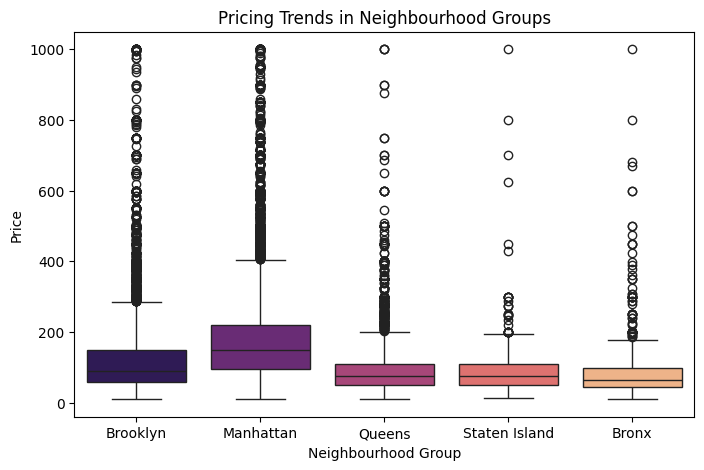

In [ ]:
mpl.figure(figsize=(8, 5))
mpl.title("Pricing Trends in Neighbourhood Groups")
mpl.xlabel("Neighbourhood Group")
mpl.ylabel("Price")
sb.boxplot(x='neighbourhood_group', y='price', data=data, hue='neighbourhood_group', palette='magma')

## Pearson Correlation
In my opinion, some interesting features of the dataset are longitude, price, minimum nights, number of reviews, and availability_365. These qualities generate interesting pairs and questions. Does a greater longitude (leads to neighbourhood groups/boroughs like Queens) lead to a greater or smaller price? Does a greater amount of availability in a year lead to a greater number of reviews? Does the minimum number of nights correlate with the pricing?

The pairings are:
(longitude, price), (longitude, minimum_nights), (longitude, number_of_reviews), (longitude, availability_365); (price, minimum_nights), (price, number_of_reviews), (price, availability_365); (minimum_nights, number_of_reviews), (minimum_nights, availability_365); (number_of_reviews, availability_365).

<Axes: title={'center': 'Pearson Correlation Coefficient Heatmap of Interesting Features'}>

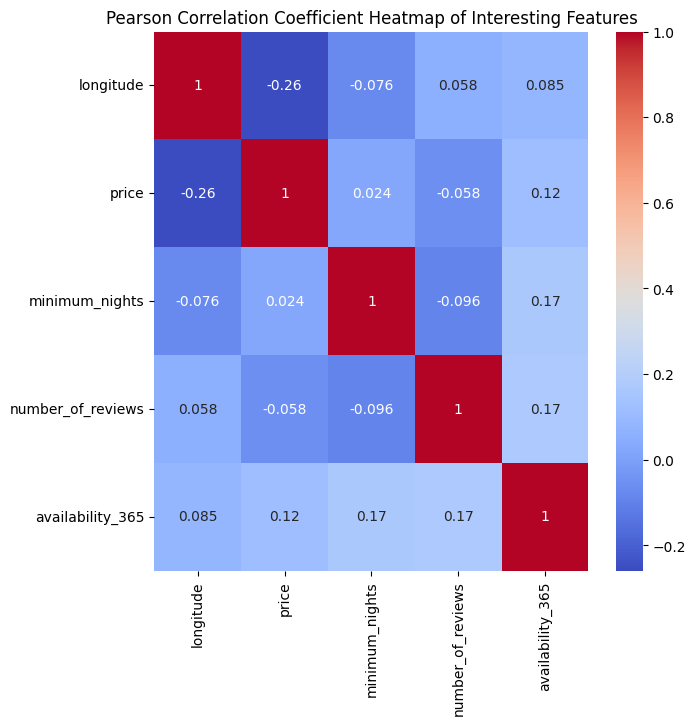

In [ ]:
interesting_feats = data[['longitude', 'price', 'minimum_nights', 'number_of_reviews', 'availability_365']] # Creating a DataFrame of the features
p_corr = interesting_feats.corr() # Calculating the Pearson Correlation Coefficient

mpl.figure(figsize=(7, 7))
mpl.title("Pearson Correlation Coefficient Heatmap of Interesting Features")
sb.heatmap(p_corr, annot=True, cmap='coolwarm')

The main diagonal (top left to bottom right cells) is represented with *r* =1 because it relates the variable to itself. The negative *r*    pairings are (longitude, price), (longitude, minimum_nights), (number_of_reviews, price), and (number_of_reviews, minimum_nights). To begin, negative Pearson correlation coefficients demonstrate a negatively linear relationship. Since the magnitude of all these coefficients are less than 0.5, even more tightly bounded by 0.3, it has no correlation or weak correlation. A positive Pearson correlation coefficient would signify that as one increases, the other does too. The most positive correlations are (number_of_reviews, availability_365) and (minimum_nights, availability_365). The most negative would be (longitude, price). To explain some of the values:

### r_(longitude, price) = -0.26
The further east (greater longitude) leads to a lower price; this might be explained because further east could be further away from Manhattan, where tons of tourist attractions are (since Airbnb tends to be used by tourists). Being closer in proximity to a tourist attraction would result in a reasonably greater price.

### r_(price, minimum_nights) = 0.024
While I thought there would be more of a correlation as a business/money-minded individual would try to get a greater amount of money if there are less minimum nights. Additionally, a greater minimum number of nights with a lesser price would be more appealable. However, as shown by the Pearson correlation coefficient, there is a very, very weak positive (as one grows, the other does too) correlation between the two variables.

### r_(minimum_nights, number_of_reviews) = -0.096
This may be considered a weak negative correlation. Thus, as one of the variable increases, the amount of the other decreases. For instance, as a host requires a greater minimum number of nights reserved, there would be less reviews for the listings. This could be explained as people would lean towards less minimum number of nights, possibly leading to more people reserving, and possibly leading to more people reviewing. However, it is still considered weak.

### r_(minimum_nights, availability_365) = 0.17
This is also considered a weak positive correlation. There is a weak linear relationship between the minimum number of nights and how many days the place is available.

### r_(number_of_reviews, availability_365) = 0.17
Following the previous, there is a weak positive correlation. The number of reviews are in a weak linear relationship with the number of available days.

## Latitude and Longitude

<Axes: title={'center': 'Geographic Coordinates of Airbnb Listings by Neighbourhood Group'}, xlabel='Longitude', ylabel='Latitude'>

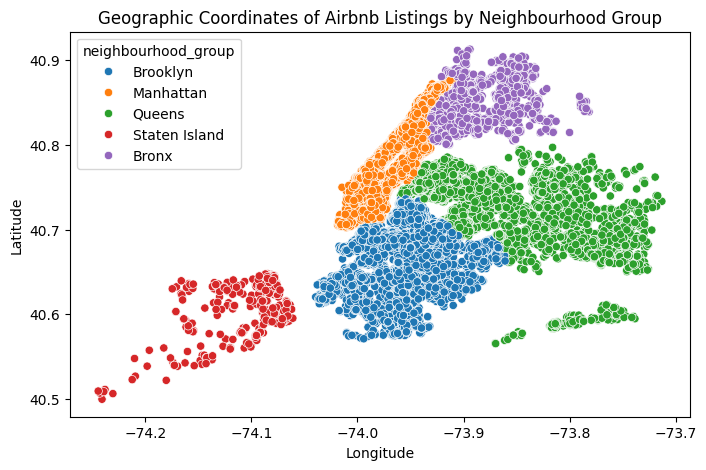

In [ ]:
lat_long_neigh = data[['neighbourhood_group', 'latitude', 'longitude']] # Creating a DataFrame focused on the neighbourhood group and geographic coordinates

mpl.figure(figsize=(8, 5))
mpl.title("Geographic Coordinates of Airbnb Listings by Neighbourhood Group")
mpl.xlabel("Longitude")
mpl.ylabel("Latitude")
sb.scatterplot(x='longitude', y='latitude', data=lat_long_neigh, hue='neighbourhood_group')

<Axes: title={'center': 'Airbnb Prices by Neighbourhood Group'}, xlabel='Longitude', ylabel='Latitude'>

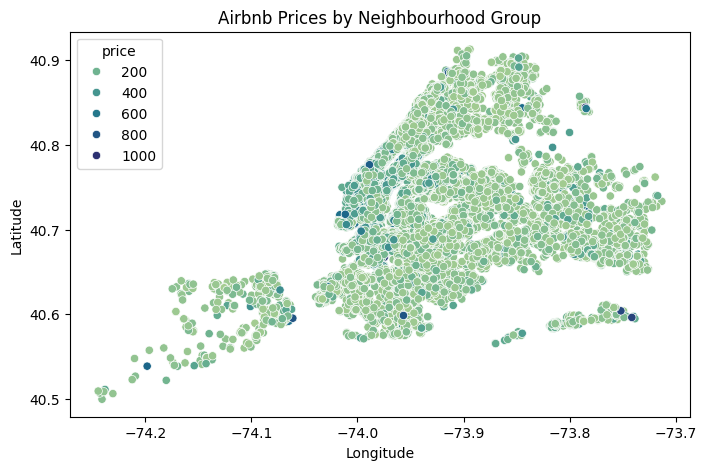

In [ ]:
lat_long_price = data[['neighbourhood_group', 'price', 'latitude', 'longitude']] # Since the data was already capped by price at 1000, it does not need to be again

mpl.figure(figsize=(8, 5))
mpl.title("Airbnb Prices by Neighbourhood Group")
mpl.xlabel("Longitude")
mpl.ylabel("Latitude")
sb.scatterplot(x='longitude', y='latitude', data=lat_long_price, hue='price', palette='crest')

Given that the majority of the darker points, which represent higher prices, are located in Manhattan, I am able to tell that Manhattan is likely the most expensive neighborhood group to stay in.

## Word Cloud with Airbnb
Some of the words that appear the most is "Private," "Room," and "Beautiful."

Text(0.5, 1.0, 'Word Cloud of Airbnb Names')

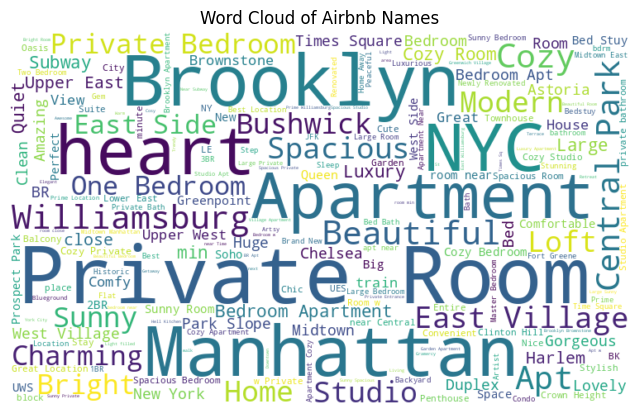

In [ ]:
text = " ".join(data['name']) # Joins all the words in the name column; no further cleaning is really needed as it any missing was replaced with 'N/A'

wordcloud = WordCloud(width=750, height=450, background_color='white').generate(text)
mpl.figure(figsize=(8, 5))
mpl.imshow(wordcloud, interpolation='bilinear')
mpl.axis('off')
mpl.title("Word Cloud of Airbnb Names")

## Busiest Host
To represent the busiest host, I chose to show the top ten with a bar chart. They will be separated by the host_id. This would best show difference in magnitude at a glance. A host could be considred very busy if they have a more listings because it would result in more places to care for: cleaning, reservation handling, and costs of ownership.

Text(0, 0.5, 'Listings')

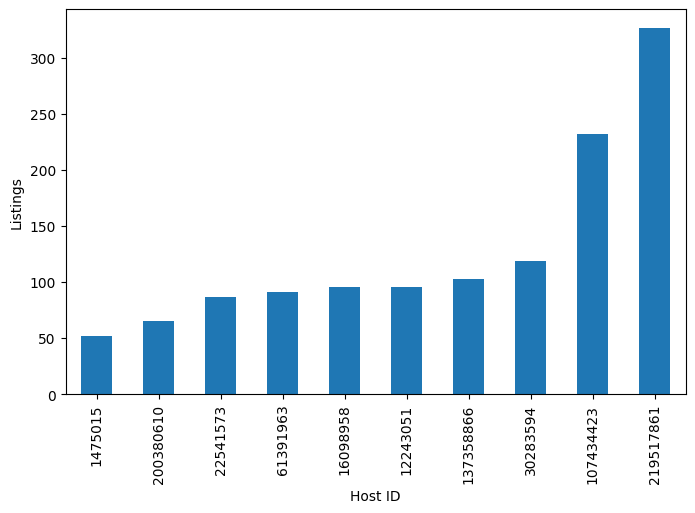

In [ ]:
host_listing_counts = data['host_id'].value_counts()
top_ten_hosts = host_listing_counts.head(10).sort_values(ascending=True) # Obtains the first ten rows of the top hosts and orders from least to greatest

top_ten_hosts.plot(kind='bar', figsize=(8, 5))
mpl.xlabel("Host ID")
mpl.ylabel("Listings")

To complement this, the Pearson correlation coefficients may be found again. This may be done by creating a new DataFrame with the counts and other columns of interest. Additionally, I created a box plot comparing the top ten hosts' average availability compared to the other hosts not recognized as one.

In [ ]:
host_data = data[['host_id', 'price', 'number_of_reviews', 'availability_365']]
host_data = host_data[host_data['host_id'].isin(top_ten_hosts.index)] # Obtaining the data of only certain listings with the top ten host_ids
host_data = host_data.groupby('host_id').mean() # Grouping all of listings made by the top ten hosts and averaging
host_data = host_data.join(top_ten_hosts) # Including the number of listings
host_data.rename(columns={'count': 'number_of_listings'}, inplace=True) # Default name was 'count' and renamed for clarity

print(host_data) # Showing what the new DataFrame looks like

                price  number_of_reviews  availability_365  number_of_listings
host_id                                                                       
1475015    103.076923           3.115385        334.115385                  52
12243051   213.031250           0.447917        276.614583                  96
16098958   208.958333           1.437500        292.322917                  96
22541573   215.436782           0.632184        312.172414                  87
30283594   263.117647           0.546218        314.075630                 119
61391963   146.241758           4.582418        241.923077                  91
107434423  303.150862           0.125000        253.810345                 232
137358866   43.825243           0.844660        196.475728                 103
200380610  290.230769           0.015385        338.030769                  65
219517861  253.195719           3.917431        301.492355                 327


In [ ]:
host_quality_corr = host_data.corr() # Finding the Pearson correlation coefficients between all the variables

print(host_quality_corr.number_of_listings) # Focusing the data on the correlation between number_of_listings and the other variables

price                 0.420724
number_of_reviews     0.226302
availability_365     -0.132789
number_of_listings    1.000000
Name: number_of_listings, dtype: float64


<Axes: title={'center': 'Availability Distribution between Top Ten Hosts and Others'}, xlabel='Type of Host', ylabel='Availability'>

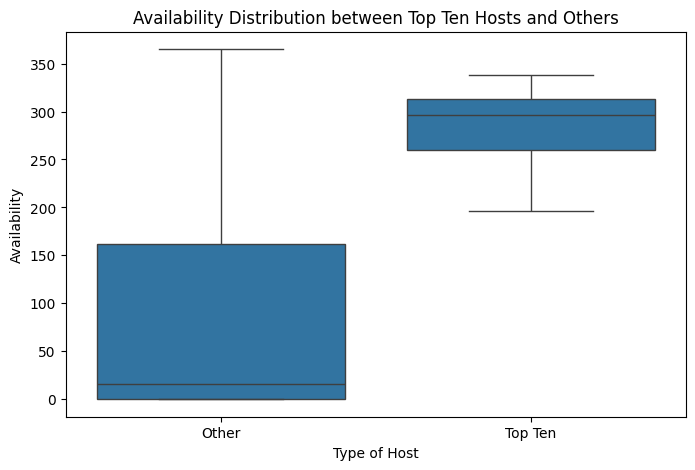

In [ ]:
avail_listing = (data[['host_id', 'availability_365']].groupby('host_id', as_index=False).mean()) # Creating a new DataFrame
avail_listing = avail_listing.join(host_listing_counts.rename('host_listing_count'),on='host_id') # Joining with the listing count
avail_listing['is_top_host'] = avail_listing['host_id'].isin(top_ten_hosts.index) # Creating a flag on who is a top ten host
avail_listing['group'] = avail_listing['is_top_host'].map({True: 'Top Ten', False: 'Other'})

mpl.figure(figsize=(8, 5))
mpl.title("Availability Distribution between Top Ten Hosts and Others")
mpl.xlabel("Type of Host")
mpl.ylabel("Availability")
sb.boxplot(x='group', y='availability_365', data=avail_listing)

As shown by the number of listings the top ten hosts have, their relationship with certain variables (e.g., price, number of reviews, availability in a year), and how they compare to other hosts in terms of availability, a busy host can be classified by how often their listings are used. There is a moderately positive relationship with price, which may demonstrate their hard-earned reward from their Airbnb rooms. Additonally, as the above box plot shows, the top ten hosts have a greater average availability than other types of hosts. Overall, a busy host may be classified by their average availability and pricing.

## Two Interesting Plots
I chose to explore the relationship between latitude and pricing. An increase in latitude means one is moving away from the equator, this would mean regions like downtown Manhattan, Astoria, and near LaGuardia airport. Prior to viewing the plot, I predict that pricing would decrease as these areas are farther away from tourist attractions. I chose to depict this relationship with a scatter plot, but a histogram may also be used (chose not to due to it taking over 1 minute to load and no clear distinction between the bars). It revealed numerous "lines" in different stages of pricing and latitudes. The majority of listings remained between a price of 0.00 and 400.00. Additionally, listings mainly clustered in the middle. This plot demonstrates that NYC Airbnb listings mainly cluster around specific areas, possibly leading to greater pricing occuring there.

<Axes: title={'center': 'Changes in Pricing based on Latitude'}, xlabel='Latitude', ylabel='Price'>

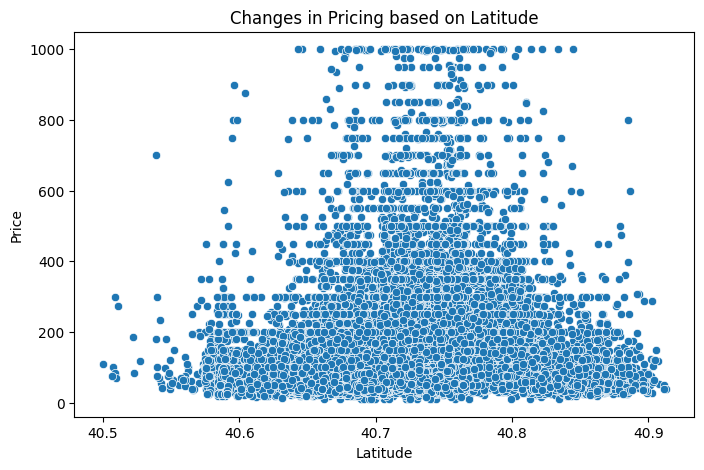

In [ ]:
mpl.figure(figsize=(8, 5))
mpl.title("Changes in Pricing based on Latitude")
mpl.xlabel("Latitude")
mpl.ylabel("Price")
sb.scatterplot(x='latitude', y='price', data=data)

For my unique plot, I wanted to use a bar chart. The relationship I am exploring is the occurrence of each type of room (name) based on the neighbourhood group. This reveals information about the number of listings in boroughs and what tourists/resevers typically look for in an Airbnb listing in New York City. The two main neighbourhood groups are Brooklyn and Manhattan, and the two main room types are private rooms and entire places. In the majority of the boroughs, there are mainly private rooms; in Manhattan, the main type is an "Entire home/apt."

<Axes: title={'center': 'Count of Types of Room in Each Neighbourhood Group'}, xlabel='Neighbourhood Group', ylabel='Count'>

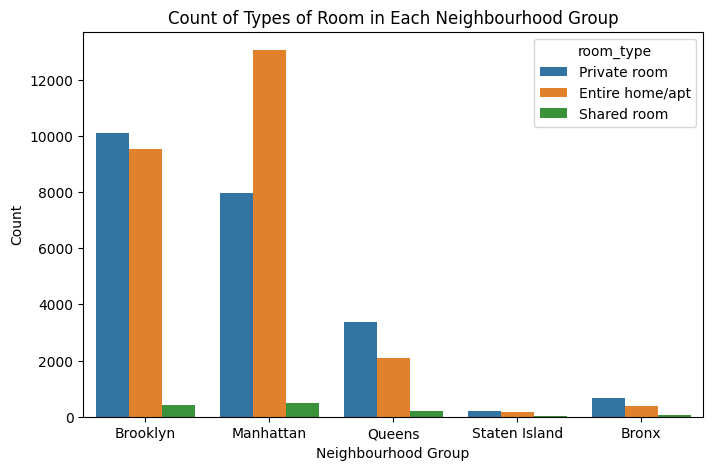

In [ ]:
mpl.figure(figsize=(8, 5))
mpl.title("Count of Types of Room in Each Neighbourhood Group")
mpl.xlabel("Neighbourhood Group")
mpl.ylabel("Count")
sb.countplot(x='neighbourhood_group', hue='room_type', data=data)